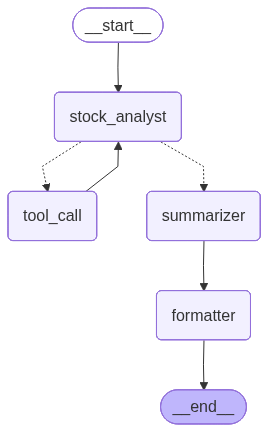

In [81]:
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, BaseMessage, ToolMessage, AIMessage
from pydantic import BaseModel, Field
from typing import List, Annotated, TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

import dotenv
import os
from pprint import pprint
from IPython.display import Image, display

dotenv.load_dotenv("../../.env")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ")

model = "llama-3.1-8b-instant"
MAX_ITERATION = 20

# output structure
# individual sector
class SectorPerformance(BaseModel):
    sector: str = Field(description="The name of the market sctor (eg. Tech, energy)")
    expected_return: float = Field(description="The forcasted return as a decimal or percentage")
    standard_deviation: float = Field(description="The measuere of risk/volatility for this sector")
    reasons: List[str] = Field(description="Reasons for the good/bad performance of the sector")

# all sectors
class MarketPerformance(BaseModel):
    market_return: List[SectorPerformance] = Field(description="A list of sector-specific financial metrics")

#tools
search_tool = DuckDuckGoSearchResults(max_results=3)
tool_list = [search_tool]
tool_mapping = {tool.name: tool for tool in tool_list}

#llm
llm = ChatGroq(
    model=model,
    temperature=0
)

# llm.invoke("what is the capital of Bosnia?")
stock_pick_message = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        You are a Europien stock market Asset Manager having years of experice 
        in evalating various sectors creating portfolios with clear focus on risk 
        return trade off.
        - IMPORTANT: you have access to the tool "duckduckgo_result_json".
        - use tool when you want to knwo the reutn or risk of a particular sector.
        - use information from reputed websites to estimate the risk return paramerts.
        - be as self critique and ask follow-up questions to validate the assumptions.
        """
    ),
    MessagesPlaceholder(variable_name="messages")
])

summarizer_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """
     You are an stock market expert. you have years of experiencing in reporting
     complex stock market concept to wider audience. 
     Write a conciese, factual summary of the expected return and risk for varius
     market sectors. Use bullet and points for each sector.
     """),
     MessagesPlaceholder(variable_name="messages")
])

formatter_prompt = ChatPromptTemplate.from_messages([
    ("system", 
     """You are a data extraction expert. Based on the reseach provided in the converstion,
    fill out the MarketPerformance schama. Only use the facts provided"""),
    MessagesPlaceholder(variable_name="messages")
])

# stock_analyst = stock_pick_message | llm.with_structured_output(MarketPerformance)
# query = "what is the expected return from various sectors in Europien market?"
# reply = stock_analyst.invoke([HumanMessage(content=query)])

# pprint(reply)

# state history
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    iteration: int

# Nodes
# the stock analyst node
def stock_analyst(state: AgentState):
    llm_with_tools = llm.bind_tools(tool_list)
    agent = stock_pick_message | llm_with_tools
    response = agent.invoke({"messages": state["messages"]})
    iteration = state["iteration"] + 1
    return {
        "messages": [response],
        "iteration": iteration
    }

# the tool call node
def tool_call_node(state: AgentState):
    # this node will handle the tool call and update the state accordingly
    last_state = state["messages"][-1]

    print("tool_call")

    tool_messages = []
    for tool_call in last_state.tool_calls:

        name = tool_call.get("name")
        args = tool_call.get("args")

        if name in tool_mapping:
            tool_response = tool_mapping[name].invoke(args)
            tool_messages.append(
                ToolMessage(
                    content = str(tool_response),
                    tool_call_id = tool_call.get("id")
                )
            )

    return {
        "messages": tool_messages #the tool_messages is a list
    }

# summarizer node
def summarizer(state: AgentState):
    chain = summarizer_prompt | llm
    response = chain.invoke({
        "messages": state["messages"]
    })
    return {
        "messages": response
    }

# formater node
def formatter(state: AgentState):
    llm_formatter = formatter_prompt | llm.with_structured_output(MarketPerformance)
    # need to invoke after the chain
    # otherwise the invoke will be for the llm
    response = llm_formatter.invoke({"messages": [state["messages"][-1]]})

    return{
        "messages": [AIMessage(content=response.model_dump_json())]
    }

# Router node
# if max_iteration reached or there is no tool_call end
def generator_router(state: AgentState):
    # check iterations to stop
    if state["iteration"] >= MAX_ITERATION:
        return "summarizer"
    
    # check the tool calls
    last_state = state["messages"][-1]
    if last_state.tool_calls:
         return "tool_call"    
    
    return "summarizer"

# generate workflow
workflow = StateGraph(AgentState)

# add nodes
workflow.add_node("stock_analyst", stock_analyst)
workflow.add_node("tool_call", tool_call_node)
workflow.add_node("formatter", formatter)
workflow.add_node("summarizer", summarizer)


# add edges
workflow.add_edge(START, "stock_analyst")
workflow.add_edge("tool_call", "stock_analyst")
workflow.add_edge("summarizer", "formatter")
workflow.add_edge("formatter", END)

# conditional edge
workflow.add_conditional_edges(
    "stock_analyst", 
    generator_router,
    # to generate the conditional edge in the graph
    {
        "tool_call": "tool_call",  
        "summarizer": "summarizer"
    }
)

# compile workflow
compiled_workflow = workflow.compile()

display(Image(compiled_workflow.get_graph().draw_mermaid_png()))


In [ ]:
query = "what is the expected return from various sectors in Europien market?"
initial_state = {
    "messages": [HumanMessage(content=query)],
    "iteration": 0
}
result = compiled_workflow.invoke(initial_state)

# pprint(result["messeges"][-1].model_dump_json())

tool_call
tool_call


KeyError: 'messeges'

In [83]:
import json
market_data = result["messages"][-1].content

market_data_dict = json.loads(market_data)
pprint(market_data_dict)

{'market_return': [{'expected_return': 0.12,
                    'reasons': ['Strong demand for digital services',
                                'Increased adoption of cloud computing'],
                    'sector': 'Tech',
                    'standard_deviation': 0.05},
                   {'expected_return': 0.08,
                    'reasons': ['Stable oil prices',
                                'Growing demand for renewable energy'],
                    'sector': 'Energy',
                    'standard_deviation': 0.03},
                   {'expected_return': 0.1,
                    'reasons': ['Low interest rates', 'Increased regulation'],
                    'sector': 'Finance',
                    'standard_deviation': 0.04},
                   {'expected_return': 0.11,
                    'reasons': ['Growing demand for healthcare services',
                                'Advancements in medical technology'],
                    'sector': 'Healthcare',
                  

In [47]:
tool_mapping

{'duckduckgo_results_json': DuckDuckGoSearchResults(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text'))}